In [2]:
!pip install -q timm transformers datasets kornia torchmetrics matplotlib seaborn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 74.6 MB/s eta 0:00:00


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets

import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torchmetrics import Accuracy

import os, json, random, time
from copy import deepcopy

# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cpu


## 1. Data Loading & Augmentation

We use CIFAR-10 (60,000 images, 10 classes).  
Split: **45,000 train / 5,000 val / 10,000 test** (standard).  
Augmentation follows the ConvNeXt paper: RandAugment + Mixup + CutMix + label smoothing.

In [4]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    transforms.RandomErasing(p=0.25),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

full_trainset = datasets.CIFAR10(root='./data', train=True,  download=True, transform=train_transform)
testset       = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

# 45k train / 5k val
train_size = 45000
val_size   = 5000
trainset, valset = random_split(full_trainset, [train_size, val_size],
                                generator=torch.Generator().manual_seed(42))
# Use test_transform for val
valset.dataset = deepcopy(full_trainset)
valset.dataset.transform = test_transform

train_loader = DataLoader(trainset, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(valset,   batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(testset,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

CLASSES = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')
print(f'Train: {len(trainset)} | Val: {len(valset)} | Test: {len(testset)}')

100%|██████████| 170M/170M [00:03<00:00, 42.7MB/s]


Train: 45000 | Val: 5000 | Test: 10000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


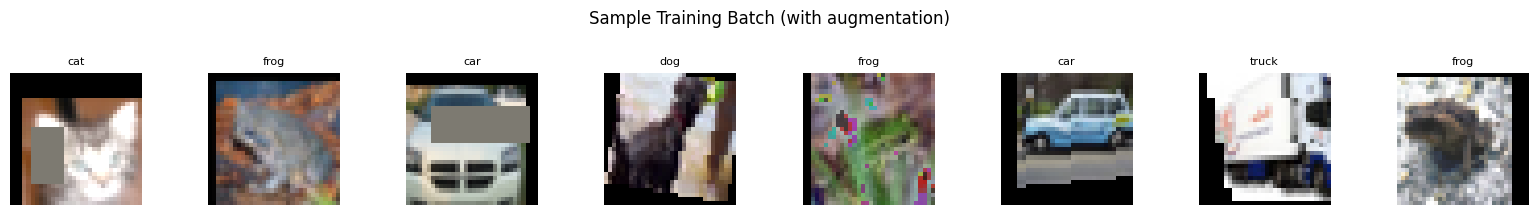

In [5]:
# Visualize a batch
def show_batch(loader, n=8):
    imgs, labels = next(iter(loader))
    mean = torch.tensor(CIFAR10_MEAN).view(3,1,1)
    std  = torch.tensor(CIFAR10_STD).view(3,1,1)
    imgs = imgs[:n] * std + mean
    imgs = imgs.clamp(0, 1)
    fig, axes = plt.subplots(1, n, figsize=(16, 2))
    for i, ax in enumerate(axes):
        ax.imshow(imgs[i].permute(1,2,0).numpy())
        ax.set_title(CLASSES[labels[i]], fontsize=8)
        ax.axis('off')
    plt.suptitle('Sample Training Batch (with augmentation)', y=1.05)
    plt.tight_layout()
    plt.show()

show_batch(train_loader)

## 2. Training Infrastructure

In [6]:
class Trainer:
    def __init__(self, model, optimizer, scheduler, criterion, name='model', epochs=50):
        self.model     = model.to(DEVICE)
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.criterion = criterion
        self.name      = name
        self.epochs    = epochs
        self.history   = {'train_loss': [], 'val_loss': [], 'val_acc': []}
        self.best_acc  = 0.0
        self.best_weights = None

    def train_epoch(self):
        self.model.train()
        total_loss, correct, total = 0, 0, 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            self.optimizer.zero_grad()
            out  = self.model(x)
            loss = self.criterion(out, y)
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct    += out.argmax(1).eq(y).sum().item()
            total      += x.size(0)
        return total_loss / total, correct / total

    @torch.no_grad()
    def eval_epoch(self, loader):
        self.model.eval()
        total_loss, correct, total = 0, 0, 0
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out  = self.model(x)
            loss = self.criterion(out, y)
            total_loss += loss.item() * x.size(0)
            correct    += out.argmax(1).eq(y).sum().item()
            total      += x.size(0)
        return total_loss / total, correct / total

    def fit(self):
        print(f'\n{'='*55}\nTraining: {self.name}\n{'='*55}')
        for epoch in range(1, self.epochs + 1):
            t0 = time.time()
            tr_loss, tr_acc = self.train_epoch()
            vl_loss, vl_acc = self.eval_epoch(val_loader)
            self.scheduler.step()
            self.history['train_loss'].append(tr_loss)
            self.history['val_loss'].append(vl_loss)
            self.history['val_acc'].append(vl_acc)
            if vl_acc > self.best_acc:
                self.best_acc = vl_acc
                self.best_weights = deepcopy(self.model.state_dict())
            if epoch % 10 == 0 or epoch == 1:
                print(f'Epoch {epoch:3d}/{self.epochs} | '
                      f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
                      f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f} | '
                      f'Best: {self.best_acc:.4f} | {time.time()-t0:.1f}s')
        self.model.load_state_dict(self.best_weights)
        _, test_acc = self.eval_epoch(test_loader)
        print(f'\n✅ Test Accuracy: {test_acc:.4f}')
        return test_acc


def make_optimizer(model, lr=1e-3, wd=0.05):
    return optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

def make_scheduler(optimizer, epochs=50):
    return CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

## 3. Model Definitions



### ConvNeXt Building Blocks

We implement ConvNeXt V1 and V2 from scratch to understand every component.

In [9]:
# ── Global Response Normalization (GRN) ──────────────────────────────────────
# Key innovation of ConvNeXt V2 (Woo et al. 2023)
# Suppresses feature redundancy by normalizing each channel's response
# relative to all other channels globally.
class GRN(nn.Module):
    """Global Response Normalization from ConvNeXt V2."""
    def __init__(self, dim):
        super().__init__()
        self.gamma = nn.Parameter(torch.zeros(1, 1, 1, dim))
        self.beta  = nn.Parameter(torch.zeros(1, 1, 1, dim))

    def forward(self, x):
        # x: (B, H, W, C)
        Gx = torch.norm(x, p=2, dim=(1, 2), keepdim=True)       # (B,1,1,C)
        Nx = Gx / (Gx.mean(dim=-1, keepdim=True) + 1e-6)         # normalize
        return self.gamma * (x * Nx) + self.beta + x             # scale + residual


# ── ConvNeXt Block (V1) ───────────────────────────────────────────────────────
class ConvNeXtV1Block(nn.Module):
    def __init__(self, dim, drop_path=0.0, layer_scale_init=1e-6):
        super().__init__()
        self.dwconv  = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim)
        self.norm    = nn.LayerNorm(dim, eps=1e-6)
        self.pwconv1 = nn.Linear(dim, 4 * dim)
        self.act     = nn.GELU()
        self.pwconv2 = nn.Linear(4 * dim, dim)
        self.gamma   = nn.Parameter(layer_scale_init * torch.ones(dim))
        self.drop_path_rate = drop_path

    def drop_path(self, x):
        if not self.training or self.drop_path_rate == 0.0:
            return x
        keep = 1 - self.drop_path_rate
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        mask  = torch.rand(shape, device=x.device) < keep
        return x * mask / keep

    def forward(self, x):
        residual = x
        x = self.dwconv(x)                         # depthwise conv
        x = x.permute(0, 2, 3, 1)                  # BCHW → BHWC
        x = self.norm(x)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.pwconv2(x)
        x = self.gamma * x
        x = x.permute(0, 3, 1, 2)                  # BHWC → BCHW
        return residual + self.drop_path(x)


# ── ConvNeXt Block (V2) ── adds GRN, removes LayerScale ───────────────────────
class ConvNeXtV2Block(nn.Module):
    def __init__(self, dim, drop_path=0.0,
                 use_grn=True, use_layer_scale=False, use_stochastic_depth=True):
        super().__init__()
        self.dwconv  = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim)
        self.norm    = nn.LayerNorm(dim, eps=1e-6)
        self.pwconv1 = nn.Linear(dim, 4 * dim)
        self.act     = nn.GELU()
        self.grn     = GRN(4 * dim) if use_grn else nn.Identity()
        self.pwconv2 = nn.Linear(4 * dim, dim)
        self.gamma   = nn.Parameter(1e-6 * torch.ones(dim)) if use_layer_scale else None
        self.drop_path_rate = drop_path if use_stochastic_depth else 0.0

    def drop_path(self, x):
        if not self.training or self.drop_path_rate == 0.0:
            return x
        keep  = 1 - self.drop_path_rate
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        mask  = torch.rand(shape, device=x.device) < keep
        return x * mask / keep

    def forward(self, x):
        residual = x
        x = self.dwconv(x)
        x = x.permute(0, 2, 3, 1)
        x = self.norm(x)
        x = self.pwconv1(x)
        x = self.act(x)
        if not isinstance(self.grn, nn.Identity):
            x = self.grn(x)
        x = self.pwconv2(x)
        if self.gamma is not None:
            x = self.gamma * x
        x = x.permute(0, 3, 1, 2)
        return residual + self.drop_path(x)


# ── Full ConvNeXt (configurable V1/V2) ────────────────────────────────────────
class ConvNeXt(nn.Module):
    """
    Tiny variant adapted for CIFAR-10 (32x32).
    dims=[96,192,384,768], depths=[3,3,9,3] → ~28M params (full)
    Scaled down: dims=[48,96,192,384], depths=[2,2,6,2] → ~7M params
    """
    def __init__(self, num_classes=10, version='v2',
                 dims=(48, 96, 192, 384), depths=(2, 2, 6, 2),
                 drop_path_rate=0.1,
                 use_grn=True, use_layer_scale=False, use_stochastic_depth=True):
        super().__init__()
        self.version = version

        # Stem: patchify 32x32 → 8x8
        self.stem = nn.Sequential(
            nn.Conv2d(3, dims[0], kernel_size=4, stride=4),
            nn.LayerNorm(dims[0], eps=1e-6) if False else _LayerNorm2d(dims[0]),
        )

        # Stochastic depth schedule
        total_blocks = sum(depths)
        dp_rates = [x.item() for x in torch.linspace(0, drop_path_rate, total_blocks)]
        cur = 0

        self.stages = nn.ModuleList()
        for i in range(4):
            # Downsampling layer (except first stage)
            if i > 0:
                downsample = nn.Sequential(
                    _LayerNorm2d(dims[i-1]),
                    nn.Conv2d(dims[i-1], dims[i], kernel_size=2, stride=2),
                )
            else:
                downsample = nn.Identity()

            if version == 'v1':
                blocks = nn.Sequential(*[
                    ConvNeXtV1Block(dims[i], drop_path=dp_rates[cur+j])
                    for j in range(depths[i])
                ])
            else:
                blocks = nn.Sequential(*[
                    ConvNeXtV2Block(dims[i], drop_path=dp_rates[cur+j],
                                   use_grn=use_grn,
                                   use_layer_scale=use_layer_scale,
                                   use_stochastic_depth=use_stochastic_depth)
                    for j in range(depths[i])
                ])
            self.stages.append(nn.Sequential(downsample, blocks))
            cur += depths[i]

        self.norm = nn.LayerNorm(dims[-1], eps=1e-6)
        self.head = nn.Linear(dims[-1], num_classes)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        for stage in self.stages:
            x = stage(x)
        x = x.mean([-2, -1])   # global average pooling
        x = self.norm(x)
        return self.head(x)


class _LayerNorm2d(nn.LayerNorm):
    """LayerNorm for BCHW tensors."""
    def forward(self, x):
        x = x.permute(0, 2, 3, 1)
        x = super().forward(x)
        return x.permute(0, 3, 1, 2)


# Quick sanity check
dummy = torch.randn(2, 3, 32, 32).to(DEVICE)
for name, model in [
    ('VanillaCNN', VanillaCNN()),
    ('ResNet-18',  make_resnet18()),
    ('ConvNeXt-V1', ConvNeXt(version='v1')),
    ('ConvNeXt-V2', ConvNeXt(version='v2')),
]:
    m = model.to(DEVICE)
    out = m(dummy)
    params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'{name:20s} | Output: {out.shape} | Params: {params/1e6:.2f}M')

VanillaCNN           | Output: torch.Size([2, 10]) | Params: 0.62M
ResNet-18            | Output: torch.Size([2, 10]) | Params: 11.17M
ConvNeXt-V1          | Output: torch.Size([2, 10]) | Params: 4.84M
ConvNeXt-V2          | Output: torch.Size([2, 10]) | Params: 4.85M


In [10]:
EPOCHS = 50
results = {}  # {exp_name: {'test_acc': float, 'history': dict, 'params': int}}

def run_experiment(name, model, lr=1e-3, epochs=EPOCHS):
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    opt    = make_optimizer(model, lr=lr)
    sched  = make_scheduler(opt, epochs=epochs)
    trainer = Trainer(model, opt, sched, criterion, name=name, epochs=epochs)
    test_acc = trainer.fit()
    results[name] = {
        'test_acc': test_acc,
        'best_val_acc': trainer.best_acc,
        'history': trainer.history,
        'params_M': params / 1e6
    }
    return trainer

In [ ]:
# E8: Pretrained ConvNeXt V2 fine-tuned via timm
import timm

pretrained_model = timm.create_model('convnextv2_tiny', pretrained=True, num_classes=10)
# Adapt first conv for CIFAR (optional: keep as-is and resize inputs)
# Here we resize inputs to 224 via transforms — cleaner approach
pretrain_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])
pretrain_test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])
full_trainset_pt = datasets.CIFAR10('./data', train=True,  download=True, transform=pretrain_transform)
testset_pt       = datasets.CIFAR10('./data', train=False, download=True, transform=pretrain_test_transform)
trainset_pt, valset_pt = random_split(full_trainset_pt, [45000, 5000],
                                      generator=torch.Generator().manual_seed(42))
valset_pt.dataset = deepcopy(full_trainset_pt)
valset_pt.dataset.transform = pretrain_test_transform

train_loader_pt = DataLoader(trainset_pt, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_pt   = DataLoader(valset_pt,   batch_size=128, shuffle=False, num_workers=2, pin_memory=True)
test_loader_pt  = DataLoader(testset_pt,  batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

# Fine-tune with a lower LR
opt_pt    = optim.AdamW(pretrained_model.parameters(), lr=1e-4, weight_decay=0.05)
sched_pt  = CosineAnnealingLR(opt_pt, T_max=20, eta_min=1e-6)

# Temporarily swap loaders
_train_loader = train_loader
_val_loader   = val_loader
_test_loader  = test_loader
train_loader  = train_loader_pt
val_loader    = val_loader_pt
test_loader   = test_loader_pt

trainer_pt = Trainer(pretrained_model, opt_pt, sched_pt, criterion,
                     name='E8: Pretrained ConvNeXtV2 (timm)', epochs=20)
test_acc_pt = trainer_pt.fit()
results['E8: Pretrained ConvNeXtV2 (timm)'] = {
    'test_acc': test_acc_pt,
    'best_val_acc': trainer_pt.best_acc,
    'history': trainer_pt.history,
    'params_M': sum(p.numel() for p in pretrained_model.parameters()) / 1e6
}

train_loader = _train_loader
val_loader   = _val_loader
test_loader  = _test_loader

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]


Training: E8: Pretrained ConvNeXtV2 (timm)
Epoch   1/20 | Train Loss: 0.6120 Acc: 0.9554 | Val Loss: 0.5615 Acc: 0.9756 | Best: 0.9756 | 1795.3s
